Developing a random forest walk for predicting Spotify song popularity from audio features

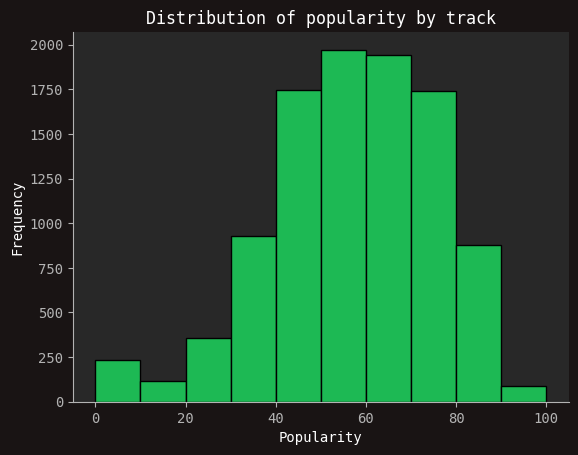

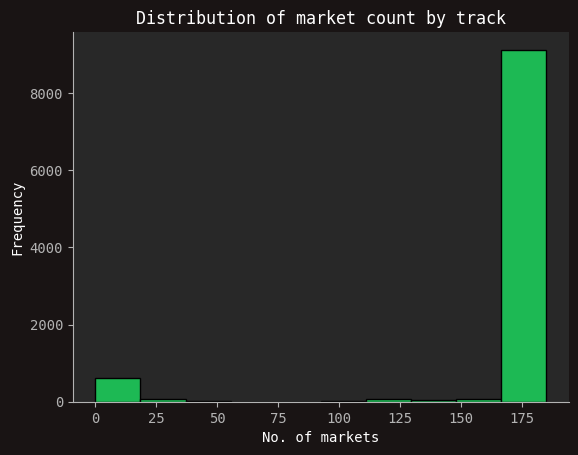

Summary of popularity:
Mean:  56.5543
Std. dev.:  18.48352919520512


In [17]:
# Setup
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
 
df = pd.read_csv("songs_merged.csv")
 
# Drop useless columns
drop_cols = ["ids", "names", "artists", "names_artist", "ids_artist", "release_date", "first_release", "last_release", "playlists_found_artist"]
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

df.head()

plt.hist(df["popularity"], color = "#1DB954", edgecolor = "black")
plt.xlabel("Popularity")
plt.ylabel("Frequency")
plt.title("Distribution of popularity by track")
plt.show()

plt.hist(df["markets"], color = "#1DB954", edgecolor = "black")
plt.xlabel("No. of markets")
plt.ylabel("Frequency")
plt.title("Distribution of market count by track")

plt.show()
print("Summary of popularity:")
print("Mean: ", np.mean(df["popularity"]))
print("Std. dev.: ", np.sqrt(np.var(df["popularity"])))


In [9]:
# Transform relevant features
# Log-transform followers and monthly listeners
df["popularity_artist"] = np.log1p(df["popularity_artist"])
df["monthly_listeners"] = np.log1p(df["monthly_listeners"])

# Scale loudness, tempo, etc.
scale_cols = ["markets", "duration_ms", "loudness", "tempo"]
df[scale_cols] = StandardScaler().fit_transform(df[scale_cols]) # technically leaking from test set here, but not target vars so nbd

# Dummy variables for categorical time signature
df = pd.get_dummies(df, columns = ["time_signature"], prefix = "ts", dtype = int)

# Create dummy genre for songs with none listed
df["genres"] = df["genres"].fillna("unknown")

df.head()

,popularity,markets,duration_ms,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,...,musicalmode,monthly_listeners,popularity_artist,followers,genres,num_releases,ts_1.0,ts_3.0,ts_4.0,ts_5.0
0,75,0.306442,-0.933622,0.0849,0.787,0.71300,0.0000,0.7170,0.603442,0.4010,...,1.0,16.791743,4.382027,7845158,"memphis hip hop, rap",20,0,0,1,0
1,29,0.306442,-0.851414,0.0291,0.728,0.88900,0.0837,0.1210,0.522782,0.0367,...,1.0,11.035035,3.332205,6460,unknown,15,0,0,1,0
2,78,0.306442,2.390896,0.0393,0.535,0.50500,0.0000,0.0923,0.225936,0.2450,...,0.0,16.545949,4.304065,2808135,"alternative r&b, conscious hip hop, hip hop, n...",10,0,0,1,0
3,40,0.306442,-0.853449,0.9770,0.220,0.00612,0.9090,0.1030,-2.183361,0.0403,...,1.0,11.688323,3.526361,209,sleep,13,0,0,1,0
4,53,0.306442,-0.899603,0.9960,0.493,0.01270,0.9550,0.0774,-1.989162,0.0600,...,0.0,12.829462,3.871201,142,unknown,7,0,0,1,0


In [10]:
# Train/test split + target-encode genre

X = df.drop(columns = ["popularity"])
y = df["popularity"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

genre_map = y_train.groupby(X_train["genres"].str.split(",").str[0].str.strip()).mean()

X_train["genres"] = X_train["genres"].str.split(",").str[0].str.strip().map(genre_map)
X_test["genres"]  = X_test["genres"].str.split(",").str[0].str.strip().map(genre_map).fillna(genre_map.mean())

X_test.head()

,markets,duration_ms,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,...,musicalmode,monthly_listeners,popularity_artist,followers,genres,num_releases,ts_1.0,ts_3.0,ts_4.0,ts_5.0
6252,0.306442,0.532866,0.717,0.373,0.334,0.000000,0.1160,0.309061,0.0367,0.620154,...,0.0,13.276652,3.891820,268231,43.620253,20,0,0,1,0
4684,0.306442,0.026533,0.122,0.652,0.806,0.000011,0.8420,0.556690,0.3020,1.340385,...,0.0,17.853041,4.477337,18253878,72.881818,20,0,0,1,0
1731,0.306442,0.776079,0.616,0.597,0.622,0.002990,0.1210,0.157401,0.3430,-1.167351,...,1.0,17.934916,4.442651,29636266,72.295858,20,0,0,1,0
4742,0.284506,0.461203,0.486,0.716,0.638,0.000000,0.0702,0.437191,0.0392,-1.083508,...,1.0,14.795782,4.158883,3314991,62.964286,19,0,0,1,0
4521,0.284506,0.336699,0.880,0.581,0.197,0.000000,0.1070,0.352216,0.0329,0.384300,...,1.0,17.122387,4.394449,1379191,57.009091,20,0,0,1,0


In [ ]:
# Model construction

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Baseline (predict all values as mean popularity)
baseline_preds = np.full(len(y_test), y_train.mean())
print("Baseline (mean) RMSE :", np.sqrt(mean_squared_error(y_test, baseline_preds)).round(3))

# Possible parameter values
param_dist = {
    "n_estimators":      [100, 200, 300, 500],
    "max_depth":         [10, 20, 30, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf":  [1, 2, 4],
    "max_features":      [0.33, "sqrt"],
}

search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    random_state=42,
)
search.fit(X_train, y_train)

Baseline (mean) RMSE : 18.257


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [10, 20, ...], 'max_features': [0.33, 'sqrt'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies t

In [ ]:
print("Best params :", search.best_params_)
print("Best CV RMSE:", (-search.best_score_).round(3))

# Evaluation on test set
rf = search.best_estimator_
preds = rf.predict(X_test)

print("\nTest set performance:")
print("  RMSE :", np.sqrt(mean_squared_error(y_test, preds)).round(3))
print("  MAE  :", mean_absolute_error(y_test, preds))
print("  R²   :", r2_score(y_test, preds))

Best params : {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.33, 'max_depth': 30}
Best CV RMSE: 6.838

Test set performance:
  RMSE : 6.518
  MAE  : 4.230830148065585
  R²   : 0.8725119510965924


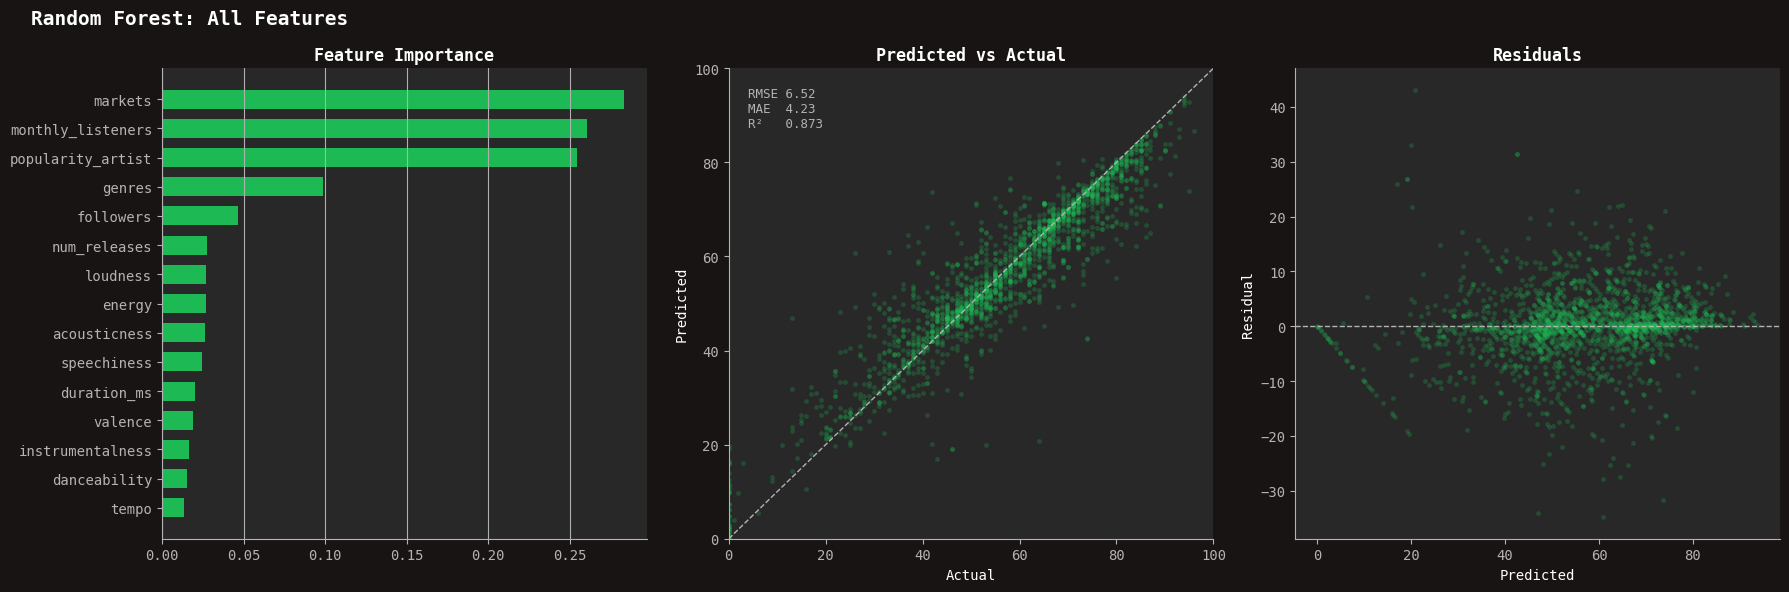

{'RMSE': np.float64(6.518), 'MAE': 4.231, 'R²': 0.873}


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
 
plt.rcParams.update({"figure.facecolor": "#191414", "axes.facecolor": "#282828",
                     "axes.edgecolor": "#B3B3B3", "axes.labelcolor": "white",
                     "xtick.color": "#B3B3B3", "ytick.color": "#B3B3B3",
                     "text.color": "white", "font.family": "monospace",
                     "axes.spines.top": False, "axes.spines.right": False})
 
def eval_model(model, X_te, y_te, title):
    preds  = model.predict(X_te)
    resids = y_te.values - preds
 
    # Permutation importance
    imp = permutation_importance(model, X_te, y_te, n_repeats=10, random_state=42, n_jobs=-1)
    imp_df = pd.DataFrame({"feature": X_te.columns, "importance": imp.importances_mean}
                         ).sort_values("importance", ascending=False).head(15)
 
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor="#191414")
    fig.suptitle(title, fontsize=14, fontweight="bold", x=0.02, ha="left")
    GREEN = "#1DB954"
 
    # Feature importance
    axes[0].barh(imp_df["feature"][::-1], imp_df["importance"][::-1], color=GREEN, height=0.65)
    axes[0].set_title("Feature Importance", fontweight="bold")
    axes[0].xaxis.grid(True)
 
    # Predicted vs Actual
    axes[1].scatter(y_te, preds, alpha=0.25, s=12, color=GREEN, linewidths=0)
    axes[1].plot([0, 100], [0, 100], color="#B3B3B3", linewidth=1, linestyle="--")
    axes[1].set(xlim=[0,100], ylim=[0,100], xlabel="Actual", ylabel="Predicted")
    axes[1].set_title("Predicted vs Actual", fontweight="bold")
    rmse, mae, r2 = np.sqrt(mean_squared_error(y_te, preds)), mean_absolute_error(y_te, preds), r2_score(y_te, preds)
    axes[1].text(0.04, 0.96, f"RMSE {rmse:.2f}\nMAE  {mae:.2f}\nR²   {r2:.3f}",
                 transform=axes[1].transAxes, va="top", fontsize=9, color="#B3B3B3")
 
    # Residuals
    axes[2].scatter(preds, resids, alpha=0.25, s=12, color=GREEN, linewidths=0)
    axes[2].axhline(0, color="#B3B3B3", linewidth=1, linestyle="--")
    axes[2].set(xlabel="Predicted", ylabel="Residual")
    axes[2].set_title("Residuals", fontweight="bold")
 
    plt.tight_layout()
    plt.savefig(f"{title.replace(' ', '_')}.png", dpi=150, bbox_inches="tight", facecolor="#191414")
    plt.show()
    return {"RMSE": round(rmse, 3), "MAE": round(mae, 3), "R²": round(r2, 3)}
 
# Full model
m1 = eval_model(rf, X_test, y_test, "Random Forest: All Features")
print(m1)

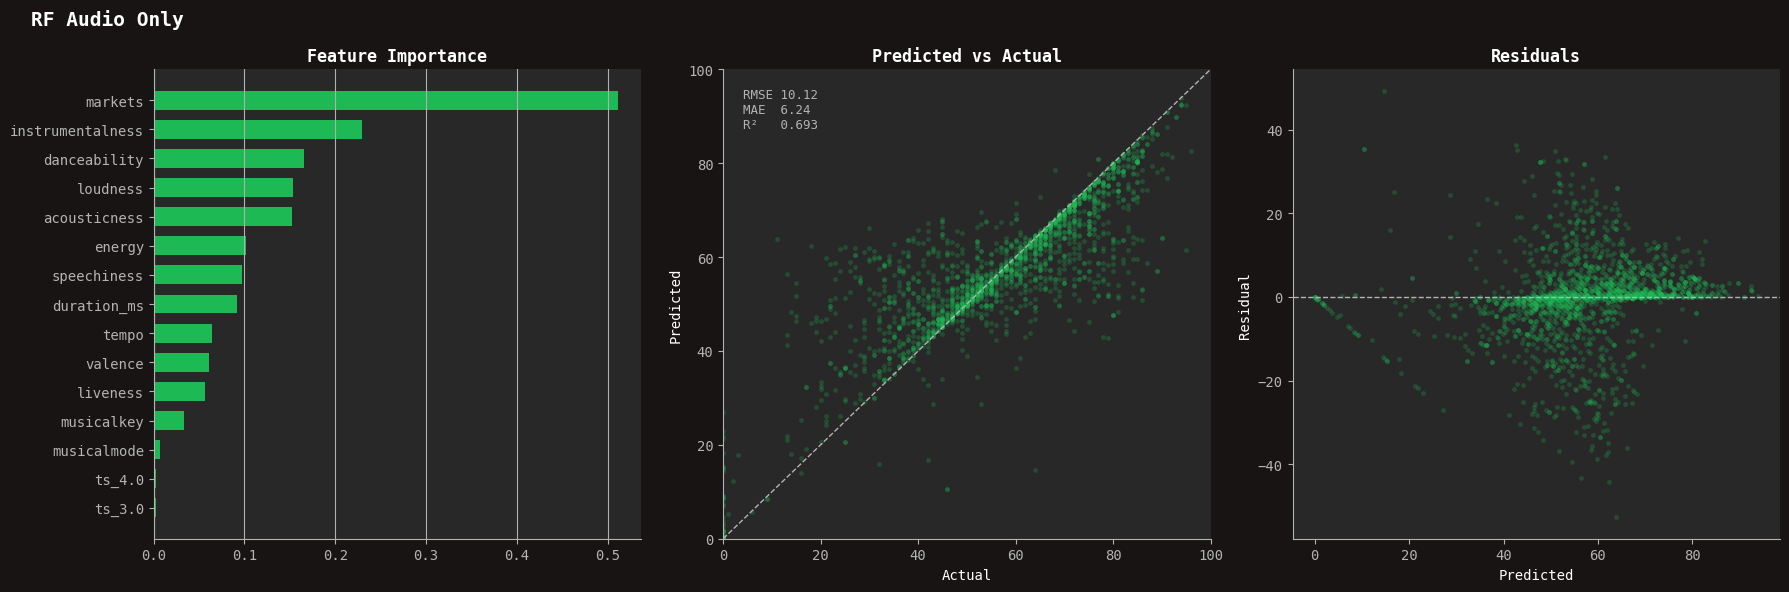

{'RMSE': np.float64(10.121), 'MAE': 6.237, 'R²': 0.693}


In [ ]:
# Audio-only model
ARTIST_COLS = ["followers", "monthly_listeners", "popularity_artist", "genres", "num_releases"]
drop = [c for c in ARTIST_COLS if c in X_train.columns]
 
rf_audio = RandomForestRegressor(**search.best_params_, random_state=42)
rf_audio.fit(X_train.drop(columns=drop), y_train)
m2 = eval_model(rf_audio, X_test.drop(columns=drop), y_test, "RF Audio Only")
print(m2)

In [ ]:
# Comparison
baseline = {"RMSE": round(np.sqrt(mean_squared_error(y_test, np.full(len(y_test), y_train.mean()))), 3),
            "MAE": round(mean_absolute_error(y_test, np.full(len(y_test), y_train.mean())), 3), "R²": 0.0}
print(pd.DataFrame({"Baseline": baseline, "RF Audio Only": m2, "RF All Features": m1}).T.to_string())

                   RMSE     MAE     R²
Baseline         18.257  14.665  0.000
RF Audio Only    10.121   6.237  0.693
RF All Features   6.518   4.231  0.873
